In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/pratyush/CAENReader")
import CAENReader
import wavedumpReader

In [2]:
def read_n_triggers_to_dataframe(file_path, n_triggers):
    """
    Read triggers from a WaveDump raw binary file using the DataFile class
    and return a pandas DataFrame.

    Parameters
    ----------
    file_path : str
        Path to the raw binary file.

    n_triggers : int or str
        Number of triggers to read.
        - If an integer: reads up to that many triggers.
        - If "all": reads all triggers until end of file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing trigger metadata and the full RawTrigger object.
        Each row corresponds to one trigger and includes:
        - trigger index
        - file position
        - board/channel information
        - event counter
        - trigger timestamp (tag and converted time)
        - waveform trace
    """

    # Initialize the WaveDump reader
    Reader = wavedumpReader.DataFile(file_path)

    rows = []  # list to store each trigger as a dictionary
    i = 0      # trigger counter

    while True:
        # Stop if a finite number of triggers is requested
        if n_triggers != "all" and i >= n_triggers:
            break

        # Read next trigger from file
        trigger = Reader.getNextTrigger()

        # Stop if end of file is reached
        if trigger is None:
            print(f"Reached end of file after reading {i} triggers.")
            break

        # Append trigger information as a dictionary
        rows.append({
            "trigger_index": i,  # sequential index in this readout
            "file_name": Reader.fileName,  # source file
            "file_pos": getattr(trigger, "filePos", None),  # byte position in file
            "board_id": getattr(trigger, "boardId", None),  # board identifier
            "pattern": getattr(trigger, "pattern", None),  # trigger pattern
            "channel": getattr(trigger, "channel", None),  # channel number
            "event_counter": getattr(trigger, "eventCounter", None),  # event ID
            "trigger_time_tag": getattr(trigger, "triggerTimeTag", None),  # raw timestamp
            "trigger_time_us": getattr(trigger, "triggerTime", None),  # converted time (µs)
            "trace_length": len(trigger.trace) if hasattr(trigger, "trace") else None,  # waveform length
            "trace": trigger.trace if hasattr(trigger, "trace") else None,  # waveform data
            "trigger_obj": trigger  # full RawTrigger object (for advanced use)
        })

        i += 1  # increment trigger counter

    # Convert list of dictionaries into a pandas DataFrame
    df = pd.DataFrame(rows)

    return df

def read_n_triggers_metadata_only(file_path, n_triggers):
    Reader = DataFile(file_path)
    rows = []

    for i in range(n_triggers):
        trigger = Reader.getNextTrigger()

        if trigger is None:
            print(f"Reached end of file after reading {i} triggers.")
            break

        rows.append({
            "trigger_index": i,
            "file_name": Reader.fileName,
            "file_pos": getattr(trigger, "filePos", None),
            "board_id": getattr(trigger, "boardId", None),
            "pattern": getattr(trigger, "pattern", None),
            "channel": getattr(trigger, "channel", None),
            "event_counter": getattr(trigger, "eventCounter", None),
            "trigger_time_tag": getattr(trigger, "triggerTimeTag", None),
            "trigger_time_us": getattr(trigger, "triggerTime", None),
            "trace_length": len(trigger.trace) if hasattr(trigger, "trace") else None,
            "trigger_obj": trigger
        })

    return pd.DataFrame(rows)

In [6]:
! ls data_testing/NEXUS_23_april_2026/wave0.dat

wave0.dat  wave1.dat


In [28]:
#events = read_float_waveform("wave0.dat")
#events_ch_0 = read_n_triggers_to_dataframe("wave0.dat", 1000)
events_ch_0 = read_n_triggers_to_dataframe("data_testing/NEXUS_23_april_2026/wave0.dat", "all")
events_ch_0.head()

Reached end of file after reading 66495 triggers.


,trigger_index,file_name,file_pos,board_id,pattern,channel,event_counter,trigger_time_tag,trigger_time_us,trace_length,trace,trigger_obj
0,0,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,24,None,0,0,69564,103800,1660.800,1030,"[8208, 8191, 8205, 8193, 8192, 8204, 8191, 819...",<wavedumpReader.RawTrigger object at 0x7ade9f3...
1,1,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,2108,None,0,0,69565,123002,1968.032,1030,"[8189, 8195, 8204, 8189, 8204, 8195, 8192, 820...",<wavedumpReader.RawTrigger object at 0x7ade9cd...
2,2,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,4192,None,0,0,69566,17201,275.216,1030,"[2887, 2890, 2900, 2884, 2895, 2890, 2884, 290...",<wavedumpReader.RawTrigger object at 0x7ade9cd...
3,3,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,6276,None,0,0,69567,36399,582.384,1030,"[8206, 8195, 8204, 8194, 8198, 8209, 8195, 819...",<wavedumpReader.RawTrigger object at 0x7ade9cd...
4,4,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,8360,None,0,0,69568,55571,889.136,1030,"[8188, 8199, 8204, 8189, 8206, 8192, 8191, 821...",<wavedumpReader.RawTrigger object at 0x7ade9cd...


In [29]:
#events_ch_1 = read_n_triggers_to_dataframe("wave1.dat", 1000)
events_ch_1 = read_n_triggers_to_dataframe("data_testing/NEXUS_23_april_2026/wave1.dat", "all")
events_ch_1.head()

Reached end of file after reading 66495 triggers.


,trigger_index,file_name,file_pos,board_id,pattern,channel,event_counter,trigger_time_tag,trigger_time_us,trace_length,trace,trigger_obj
0,0,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,24,None,0,1,69564,103800,1660.800,1030,"[8195, 8191, 8192, 8189, 8191, 8190, 8192, 819...",<wavedumpReader.RawTrigger object at 0x7ade9cd...
1,1,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,2108,None,0,1,69565,123002,1968.032,1030,"[8192, 8190, 8191, 8191, 8190, 8194, 8196, 819...",<wavedumpReader.RawTrigger object at 0x7ade9a3...
2,2,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,4192,None,0,1,69566,17201,275.216,1030,"[8191, 8194, 8193, 8191, 8195, 8191, 8190, 819...",<wavedumpReader.RawTrigger object at 0x7ade9a3...
3,3,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,6276,None,0,1,69567,36399,582.384,1030,"[8192, 8194, 8189, 8193, 8189, 8189, 8193, 819...",<wavedumpReader.RawTrigger object at 0x7ade9a4...
4,4,/home/pratyush/WaveDump_soft_x730/wavedump-v3....,8360,None,0,1,69568,55571,889.136,1030,"[8193, 8195, 8191, 8189, 8195, 8190, 8194, 819...",<wavedumpReader.RawTrigger object at 0x7ade9a4...


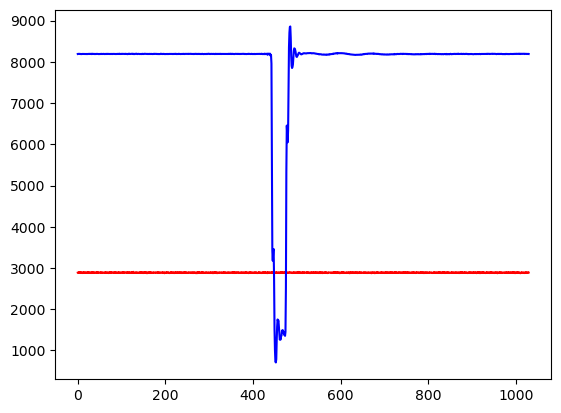

In [12]:
event_id= 2
trace0_ch0 = events_ch_0.loc[event_id, "trace"]
trace0_ch1 = events_ch_1.loc[event_id, "trace"]

plt.plot(trace0_ch0, 'r')
plt.plot(trace0_ch1, 'b')

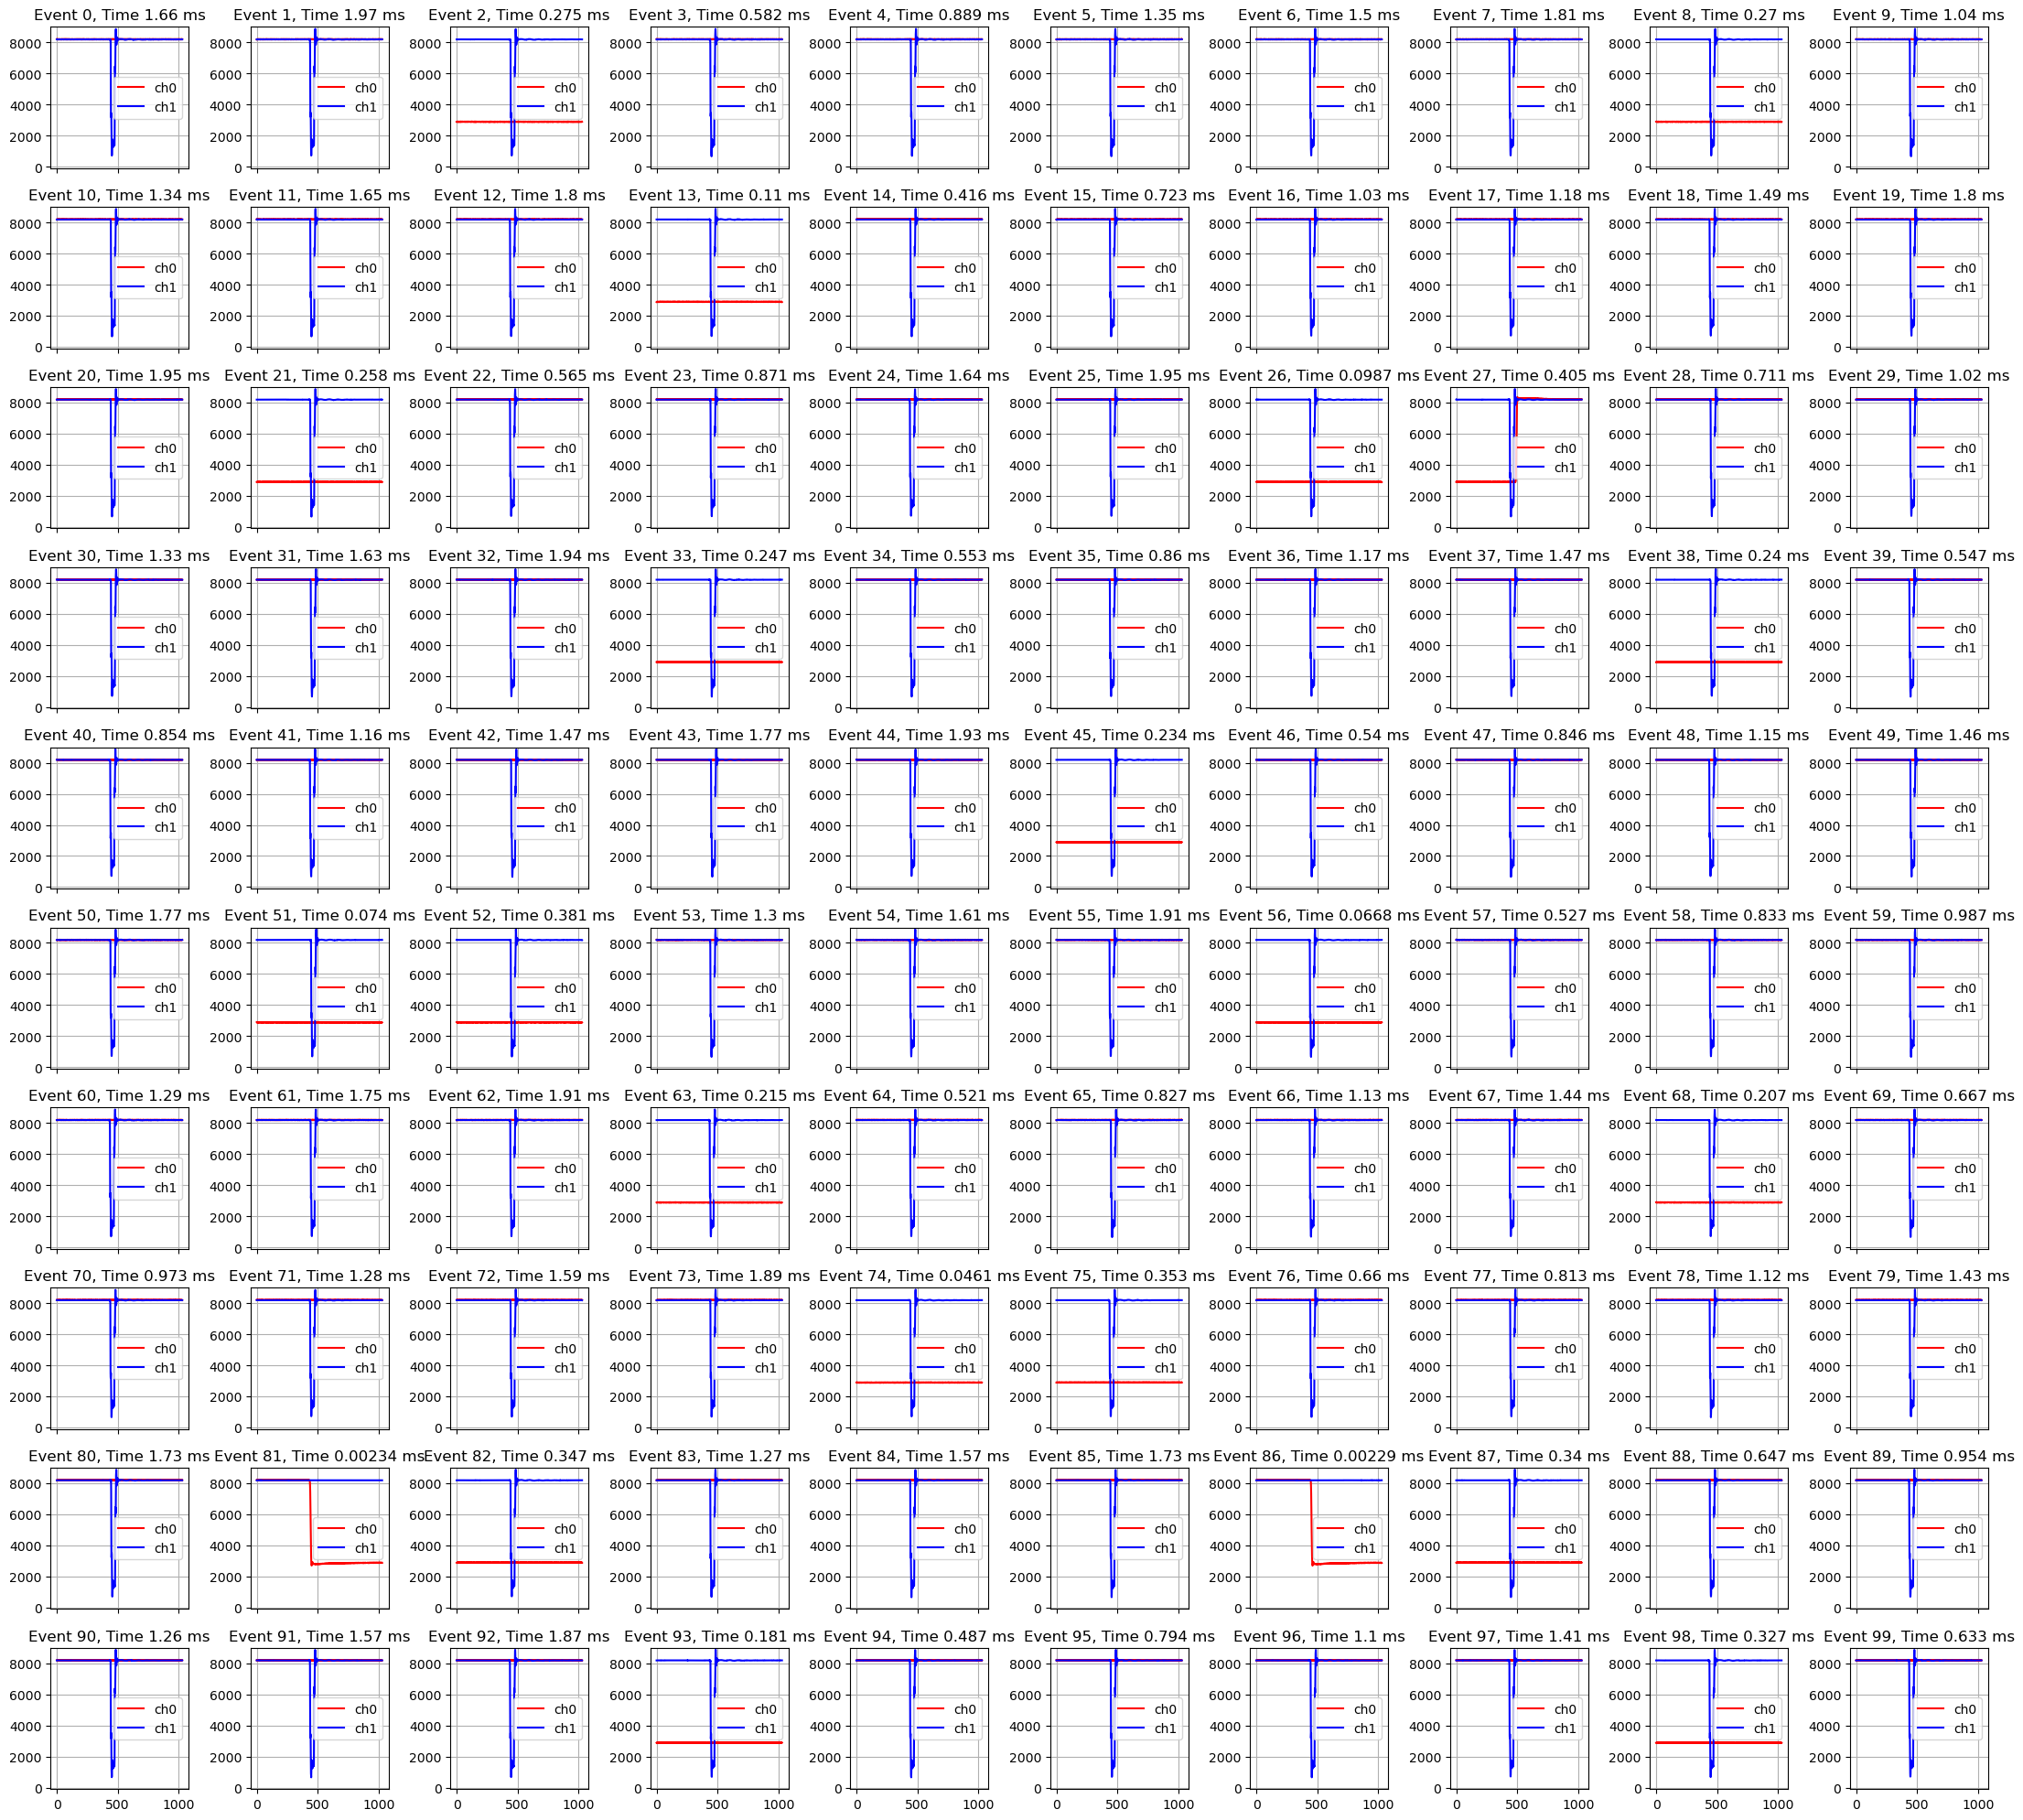

In [21]:
fig, axes = plt.subplots(10, 10, figsize=(22, 20), sharex=True)
axes = axes.flatten()

start_event_id =0
for i in range(100):
    event_id = start_event_id + i

    # Get traces
    trace0 = events_ch_0.loc[event_id, "trace"]
    trace1 = events_ch_1.loc[event_id, "trace"]

    ax = axes[i]

    #ax.plot(trace0-np.mean(trace0[:100]), 'r', label='ch0')
    #ax.plot(trace1-np.mean(trace1[:100]), 'b', label='ch1')

    ax.plot(trace0, 'r', label='ch0')
    ax.plot(trace1, 'b', label='ch1')

    ax.set_title(
    f"Event {event_id}, Time {((events_ch_0.trigger_time_us[event_id]) / 1000):.3g} ms"
)
    ax.grid(True)
    #ax.set_ylim(-100,10000)
    ax.set_ylim(-100,9000)

    # Only add legend to first plot (cleaner)
    #if i == 0:
    ax.legend()

plt.tight_layout()
plt.show()

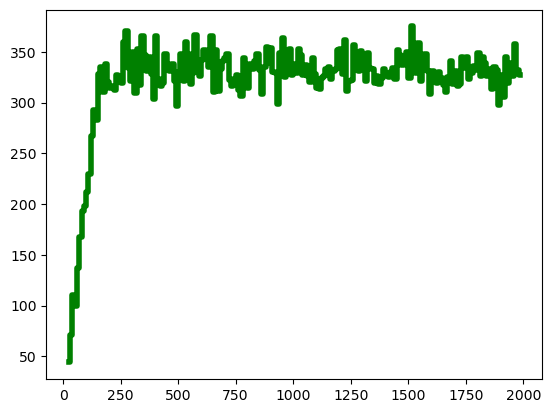

In [33]:
n_CPD,bins=np.histogram(events_ch_0.trigger_time_us, bins=np.arange(20,2000,10))

#plt.hist( Helium[b'TotalE_AlFilm'], bins=np.arange(0,6,0.001),\
#             histtype='stepfilled', alpha=0.3, color='green')

plt.step(0.5*(bins[1:] + bins[:-1]), n_CPD , where='mid',color='g',linestyle='-',linewidth=4,\
        label= "Al Film")

In [12]:
np.array(events_ch_0.trigger_time_us)

array([  2.32 , 440.656,   2.32 ,   6.832, 440.56 ,   2.32 , 440.464,
         2.336,   7.008, 440.384,   2.304, 440.672,   2.336,   7.008,
       440.288,   2.32 , 440.656,   2.304, 440.48 ,   2.32 , 440.72 ,
         2.32 ,   6.896, 440.304,   2.304, 440.512,   2.32 , 440.432,
         2.32 , 440.496,   2.32 , 440.656,   2.32 , 440.496,   2.336,
       440.288,   2.32 , 440.528,   2.336,   6.848, 440.544,   2.352,
         6.896, 440.784,   2.336, 440.32 ,   2.336, 440.48 ,   2.352,
         7.024, 440.304,   2.336, 440.768,   2.336, 440.32 ,   2.336,
         6.88 , 440.672,   2.32 ,   6.896, 440.624,   2.32 , 440.656,
         2.304, 440.64 ,   2.304, 440.672,   2.336, 440.224,   2.32 ,
       440.528,   2.304, 440.48 ,   2.32 , 440.496,   2.32 , 440.496,
         2.336,   6.816, 440.768,   2.336, 440.672,   2.352, 440.528,
         2.336, 440.512,   2.32 ,   6.832, 440.784,   2.336, 440.288,
         2.352, 440.688,   2.336, 440.48 ,   2.304, 440.672,   2.32 ,
       440.496,   2.

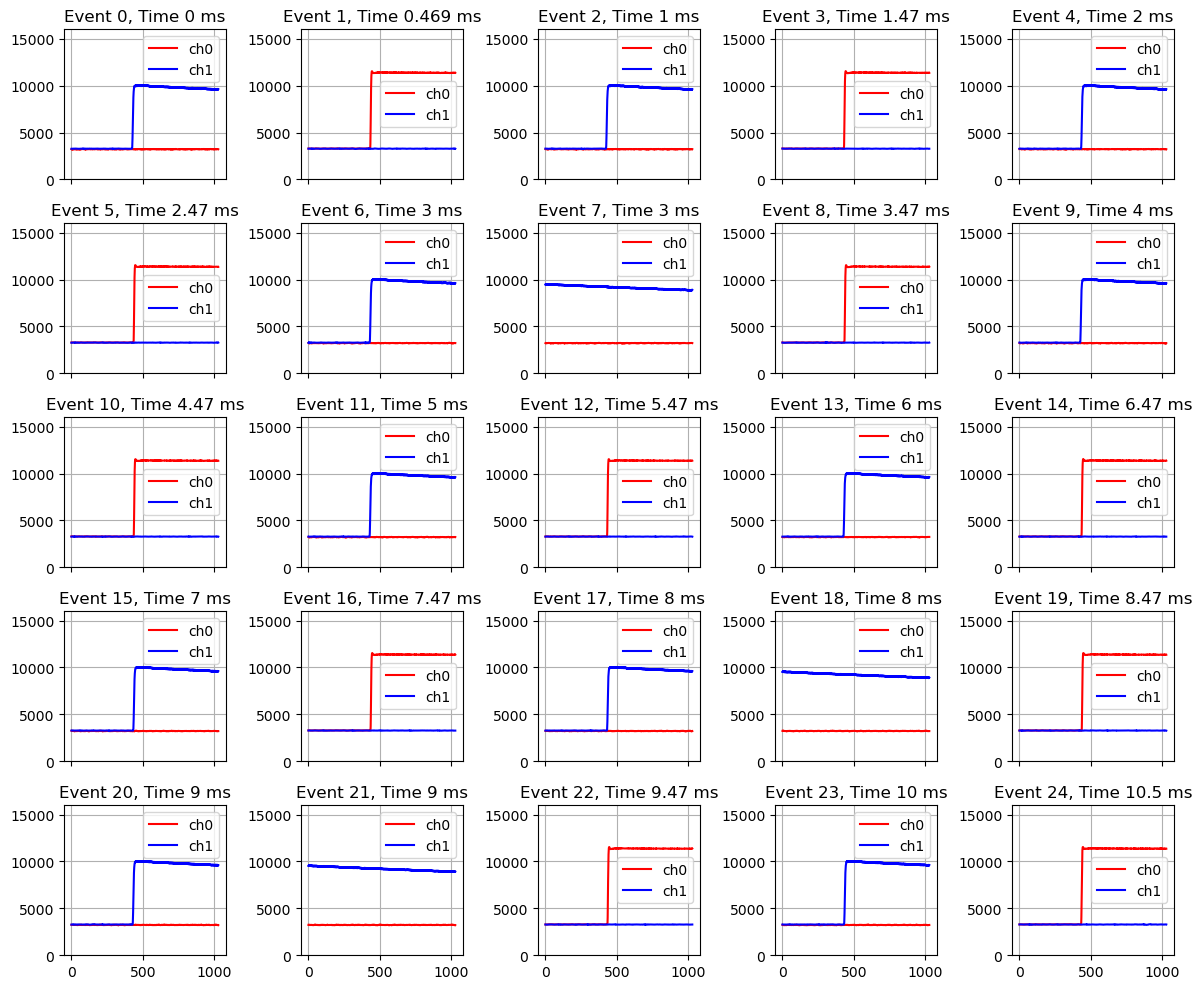

In [5]:
fig, axes = plt.subplots(5, 5, figsize=(12, 10), sharex=True)
axes = axes.flatten()

start_event_id =0
for i in range(25):
    event_id = start_event_id + i

    # Get traces
    trace0 = events_ch_0.loc[event_id, "trace"]
    trace1 = events_ch_1.loc[event_id, "trace"]

    ax = axes[i]

    #ax.plot(trace0-np.mean(trace0[:100]), 'r', label='ch0')
    #ax.plot(trace1-np.mean(trace1[:100]), 'b', label='ch1')

    ax.plot(trace0, 'r', label='ch0')
    ax.plot(trace1, 'b', label='ch1')

    ax.set_title(
    f"Event {event_id}, Time {((events_ch_0.trigger_time_us[event_id] - events_ch_0.trigger_time_us[0]) / 1000):.3g} ms"
)
    ax.grid(True)
    #ax.set_ylim(-100,10000)
    ax.set_ylim(0,16000)

    # Only add legend to first plot (cleaner)
    #if i == 0:
    ax.legend()

plt.tight_layout()
plt.show()

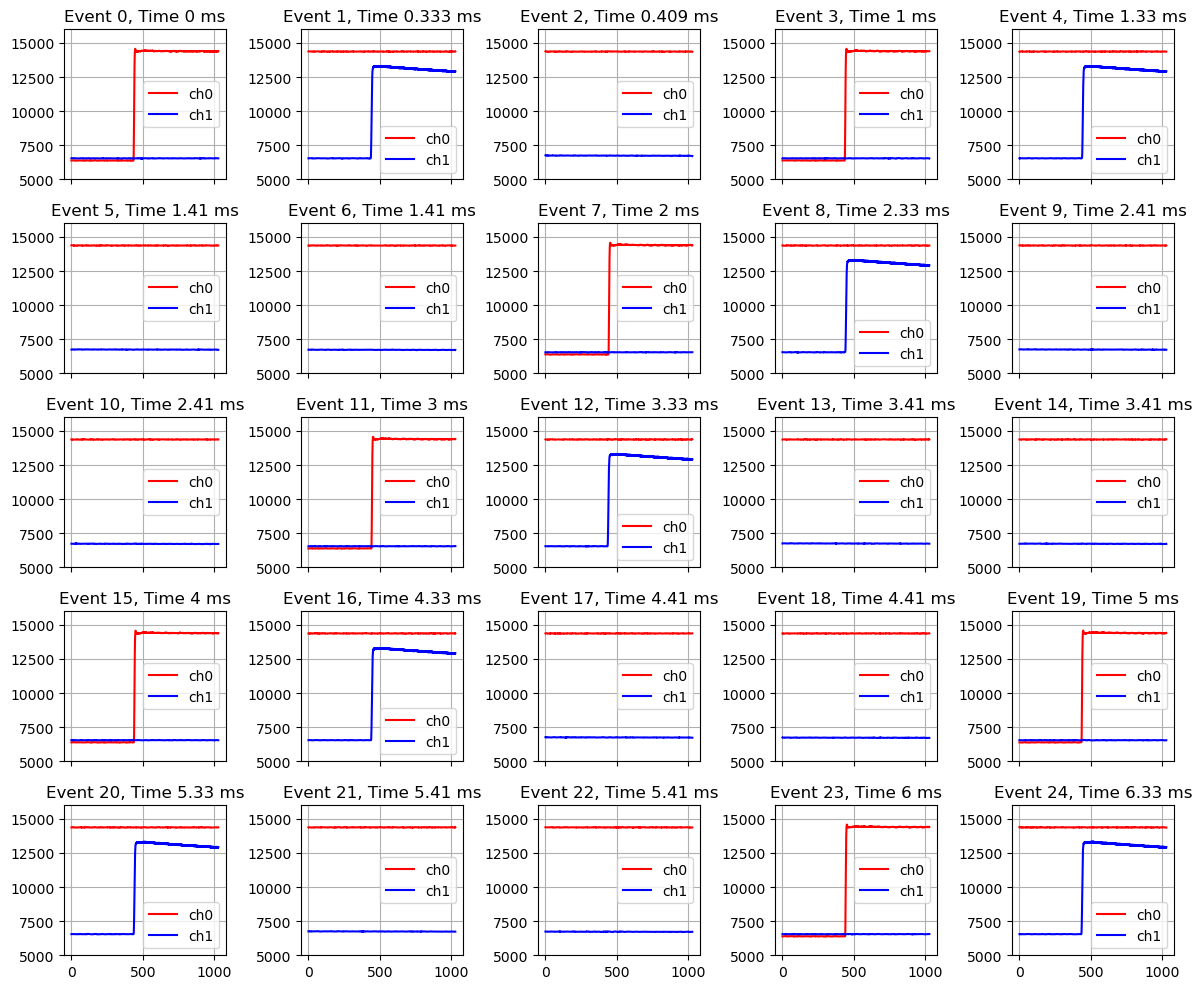

In [20]:
fig, axes = plt.subplots(5, 5, figsize=(12, 10), sharex=True)
axes = axes.flatten()

start_event_id =0
for i in range(25):
    event_id = start_event_id + i

    # Get traces
    trace0 = events_ch_0.loc[event_id, "trace"]
    trace1 = events_ch_1.loc[event_id, "trace"]

    ax = axes[i]

    #ax.plot(trace0-np.mean(trace0[:100]), 'r', label='ch0')
    #ax.plot(trace1-np.mean(trace1[:100]), 'b', label='ch1')

    ax.plot(trace0, 'r', label='ch0')
    ax.plot(trace1, 'b', label='ch1')

    ax.set_title(
    f"Event {event_id}, Time {((events_ch_0.trigger_time_us[event_id] - events_ch_0.trigger_time_us[0]) / 1000):.3g} ms"
)
    ax.grid(True)
    #ax.set_ylim(-100,10000)
    ax.set_ylim(5000,16000)

    # Only add legend to first plot (cleaner)
    #if i == 0:
    ax.legend()

plt.tight_layout()
plt.show()

In [38]:
events_ch_0.trigger_time_us[0]-events_ch_0.trigger_time_us[0]

0.0

In [37]:
events_ch_0.trigger_time_us[1]-events_ch_0.trigger_time_us[0]

228.41599999926984

In [39]:
events_ch_0.trigger_time_us[2]-events_ch_0.trigger_time_us[0]

999.9199999999255

In [40]:
events_ch_0.trigger_time_us[3]-events_ch_0.trigger_time_us[0]

1228.4000000003725

In [41]:
events_ch_0.trigger_time_us[4]-events_ch_0.trigger_time_us[0]

1999.9199999999255